#**Emotion Classification with RNNs , LSTMs & GRUs**

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU.**

##1. Import Libraries

Import Tensorflow/Keras, HuggingFace Datasets and evolution tools.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [28]:
from datasets import load_dataset

##2. Load Dataset

Load the `dair-ai/emotion` dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [29]:
# Load Dataset
# https://huggingface.co/datasets/dair-ai/emotion

emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']


In [30]:
label_names = emotion_dataset['train']['label'].features.names

In [31]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [32]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
    )

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
    )

In [33]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


###3. EDA (Exploratory Data Analysis)

In [34]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

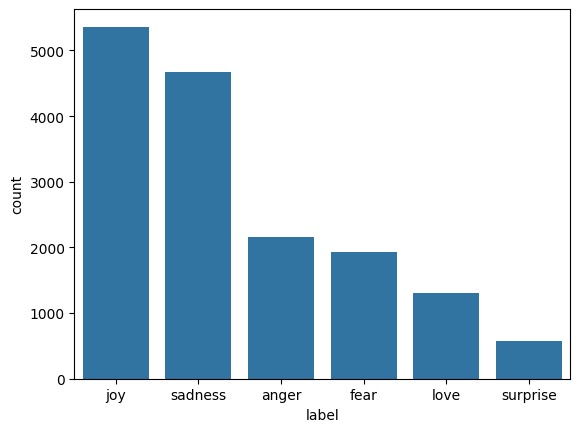

In [35]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

##4. Data Preprocessing using NLP

Tokenize text , pad sequences to max 50 length, and convert labels into Numpy arrays

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words = max_words , oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

In [37]:
train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])
train_sequence[0]

[2, 139, 3, 679]

In [38]:
padded_train_sequence = pad_sequences(train_sequence, maxlen= 50 , padding = 'post' , truncating = 'post')
padded_test_sequence =  pad_sequences(test_sequence,  maxlen= 50 , padding = 'post' , truncating = 'post')
padded_train_sequence[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

In [39]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)

In [40]:
num_classes = np.unique(train_labels)
num_of_classes = len(num_classes)
num_of_classes

6

In [41]:
print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Number of Classes: {num_of_classes}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Number of Classes: 6
Max Sentence Length: 50


##5. Shared Training Utilities

Compute balamced class weights to handle dataset skew and setup early stopping

In [42]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

dict(enumerate(class_weights))

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [43]:
class_weight_dict = dict(enumerate(class_weights))

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

##6. Phase 1 - Plain Foundational Models

Train plain (non-bidirectional) Simple RNN , Standard LSTM and Standard GRU models.

##6.1 Model - 1 Simple RNN

Plain unrolled Recurrent Neural Network

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM, GRU

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_of_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),  # Updated test_label -> test_labels
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss , rnn_accuracy = model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.1651 - loss: 2.0156 - val_accuracy: 0.2895 - val_loss: 1.7684
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.1503 - loss: 1.8654 - val_accuracy: 0.1175 - val_loss: 1.7970
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.1363 - loss: 1.8242 - val_accuracy: 0.1375 - val_loss: 1.8125
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.1273 - loss: 1.8095 - val_accuracy: 0.0330 - val_loss: 1.7996
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2895 - loss: 1.7684
RNN Loss: 1.7683976888656616
RNN Accuracy: 0.28949999809265137


##6.2 Model 2 - LSTM Model

Plain stacked Long-Short Term Memory Network

In [47]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences= True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_of_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_model.fit(padded_train_sequence, train_labels, validation_data=(padded_test_sequence, test_labels), epochs=20, batch_size=32, class_weight=class_weight_dict, callbacks=[early_stopping])

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 136ms/step - accuracy: 0.1454 - loss: 1.7950 - val_accuracy: 0.1360 - val_loss: 1.8090
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - accuracy: 0.1593 - loss: 1.7937 - val_accuracy: 0.0415 - val_loss: 1.7906
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.1673 - loss: 1.7917 - val_accuracy: 0.0815 - val_loss: 1.8135
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.1360 - loss: 1.8090
LSTM Loss: 1.8089736700057983
LSTM Accuracy: 0.13600000739097595


##6.3 Model 3 - Standard GRU

Plain stacked Long Short-Term Memory network

In [48]:
gru_model = Sequential([
    Embedding(input_dim = max_words, input_length = 50 , output_dim = 128),
    GRU(units = 128 , return_sequences = True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_of_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(padded_train_sequence, train_labels, validation_data=(padded_test_sequence, test_labels), epochs=20 , batch_size=32, class_weight = class_weight_dict, callbacks=[early_stopping])

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 113ms/step - accuracy: 0.1484 - loss: 1.7973 - val_accuracy: 0.0845 - val_loss: 1.7818
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.1579 - loss: 1.7956 - val_accuracy: 0.2895 - val_loss: 1.7884
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.1475 - loss: 1.7948 - val_accuracy: 0.3460 - val_loss: 1.7869
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0845 - loss: 1.7818
GRU Loss: 1.781846046447754
GRU Accuracy: 0.08449999988079071


##6.4 Phase 1 Ranking & Selection

Rank foundational models to pick the best base cell for Phase 2

In [49]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss ],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)

result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.768398,0.2895
1,LSTM,1.808974,0.1360
2,GRU,1.781846,0.0845


##7. Phase 2 - Advanced Bidirectional GRU

Enhance GRU with Bidirectional layers, 300D embeddings, a

##7.1 Model 4 - Advanced Stacked Birectional GRU

In [50]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim  = 300 , input_length=50),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dense(units = num_of_classes, activation = 'softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


##Train and Evaluate Advanced Bidirectional GRU

In [51]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight= class_weight_dict,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 321ms/step - accuracy: 0.6145 - loss: 0.9358 - val_accuracy: 0.8915 - val_loss: 0.3149
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 312ms/step - accuracy: 0.9249 - loss: 0.1908 - val_accuracy: 0.9115 - val_loss: 0.2489
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 155s 310ms/step - accuracy: 0.9528 - loss: 0.1108 - val_accuracy: 0.9215 - val_loss: 0.2180
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 210s 326ms/step - accuracy: 0.9672 - loss: 0.0772 - val_accuracy: 0.9115 - val_loss: 0.2702
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 314ms/step - accuracy: 0.9746 - loss: 0.0604 - val_accuracy: 0.9150 - val_loss: 0.2507
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 312ms/step - accuracy: 0.9804 - loss: 0.0479 - val_accuracy: 0.9200 - val_loss: 0.2414
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9215 - loss: 0.2180
BiGRU Loss: 0.21798788011074066
BiGRU Accuracy: 0.921500027179718


##8. Overall Evaluation & Bias Analysis

Consolidate test metrics, plot raw & normalized matrices, and analyze bias.

##8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step


<Axes: >

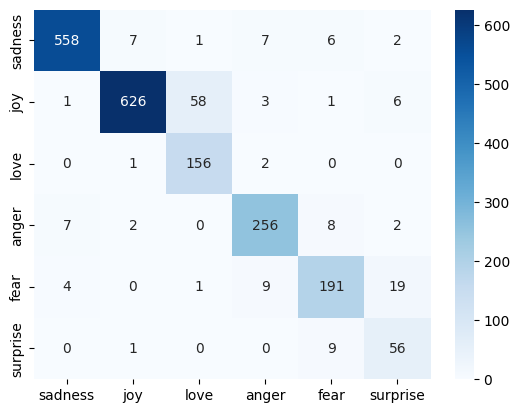

In [56]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, cmap='Blues',xticklabels=label_names, yticklabels=label_names, fmt='d')


##9. Final Predictions

Test the winning model on unseen sample sentences.

In [57]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


##10. Save Model & Tokenizer

Export trained model and tokenizer artifacts for API deployment

In [60]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok = True)

# Save the BiGUR Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer , file)